# Regressão Linear, Valor de Probabilidade e Métricas

In [1]:
# Importando bibliotecas que serão usadas: 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import csv
import math
import pandas as pd
import shutil

## A $)$ Correlação

### Geração de Gráficos, uso de Regressão Linear e cálculo de Covariância:

Gerar valores similares aos das seguintes figuras, para isso define-se primeiramente uma "semente", que define valores iniciais para geradores de números pseudoaleatórios, com o objetivo de garantir a reprodutibilidade, o que facilita futuras análises de resultado.

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="assets/atv_4/A_func1.png" width="300">
  <img src="assets/atv_4/A_func2.png" width="300">
</div>

In [50]:
np.random.seed(3994)

Função Linregress: 

A função Linregress retorna: 
- o slope(coeficiente angular) 
- o intercept(coeficiente linear) 
- o r-value(coeficiente de correlação Pearson) 
- o p-value(valor de probabilidade) 
- o stderr(erro padrão do coeficiente angular) 
- o intercept_stderr(erro padrão do coeficiente linear)

> Código para as figuras:

In [51]:
# Gráfico 1
x1 = np.random.rand(9) * 2 + 1                              # Cria um vetor com números float aleatórios entre (0,1) e os valores são multiplicados por 2 e soma por 1, é uma distribuição uniforme
y1 = x1 + 0.1                                               # Função y em que cada x da lista é somado com mais 0.1
                                                            # x1 e y1 são para o gráfico 1

media_x1 = sum(x1) / len(x1)                                # Média do X do gráfico 1
media_y1 = sum(y1) / len(y1)                                # Média do Y do gráfico 1
covariancia_1 = sum((x1[i] - media_x1) * (y1[i] - media_y1) for i in range(len(x1)) ) / (len(x1) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado1 = stats.linregress(x1, y1)                       # Nesta parte realiza-se a Regressão Linear para o gráfico 1
pvalue1 = resultado1.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 1

linha_X1 = np.linspace(0, 4, 2)                             # Se cria um vetor com valores que serão usados para desenhar o gráfico
linha_Y1 = resultado1.slope * linha_X1 + resultado1.intercept 
                                                            # Aqui se usa o slope(coeficiente angular) e o intercept(coeficiente linear)

# Gráfico 2

x2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3)
y2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3) 

media_x2 = sum(x2) / len(x2)                                # Média do X no gráfico 2
media_y2 = sum(y2) / len(y2)                                # Média do Y no gráfico 2

covariancia_2 = sum((x2[i] - media_x2) * (y2[i] - media_y2) for i in range(len(x2)) ) / (len(x2) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado2 = stats.linregress(x2, y2)                       # Regressão Linear para o gráfico 2
pvalue2 = resultado2.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 2


linha_X2 = np.linspace(0, 4, 2)
linha_Y2 = resultado2.slope * linha_X2 + resultado2.intercept

> Código dos gráficos:

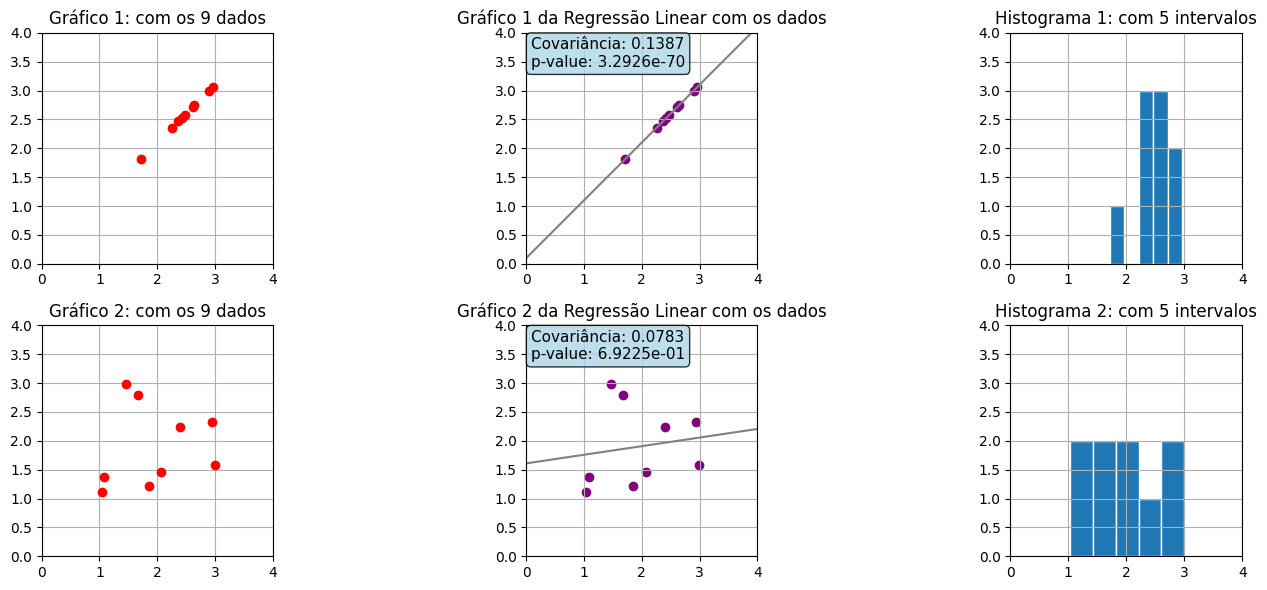

In [52]:
fig, axs= plt.subplots(2, 3, figsize=(16,6))

graph1 = axs[0,0]
graph2 = axs[0,1]
graph3 = axs[0,2]

graph4 = axs[1,0]
graph5 = axs[1,1]
graph6 = axs[1,2]


# Gráfico 1, plotando apenas os 9 pontos
graph1.plot(x1, y1, 'o', color='red')
graph1.set_title('Gráfico 1: com os 9 dados')
graph1.grid(True)
graph1.set_aspect('equal', adjustable='box')
graph1.set_xlim(0,4)
graph1.set_ylim(0,4)

# Gráfico 2, exibindo os 9 valores sob a reta e a reta da Regressão Linear 1
graph2.scatter(x1, y1, color='purple')
graph2.plot(linha_X1, linha_Y1, color='grey')
graph2.set_title('Gráfico 1 da Regressão Linear com os dados')
graph2.grid(True)
graph2.set_aspect('equal', adjustable='box')
graph2.set_xlim(0,4)
graph2.set_ylim(0,4)

info_text1 = (f"Covariância: {covariancia_1:.4f}\n" f"p-value: {pvalue1:.4e}")
graph2.text( 0.02, 0.98, info_text1, transform=graph2.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 3, mostrando o agrupamento dos 9 valores num bin = 5
graph3.hist(x1, bins=5, edgecolor='white')
graph3.set_title('Histograma 1: com 5 intervalos')
graph3.set_xlim(0,4)
graph3.set_ylim(0,4)
graph3.grid(True)
graph3.set_aspect(0.995) 

# Gráfico 4, mostrando a disposição dos dados no segundo caso
graph4.plot(x2, y2, 'o', color='red')
graph4.set_title('Gráfico 2: com os 9 dados')
graph4.grid(True)
graph4.set_aspect('equal', adjustable='box')
graph4.set_xlim(0,4)
graph4.set_ylim(0,4)

# Gráfico 5, exibindo os 9 valores sob a reta e a reta da Regressão Linear 2
graph5.scatter(x2, y2, color='purple')
graph5.plot(linha_X2, linha_Y2, color='grey')
graph5.set_title('Gráfico 2 da Regressão Linear com os dados')
graph5.grid(True)
graph5.set_aspect('equal', adjustable='box')
graph5.set_xlim(0,4)
graph5.set_ylim(0,4)

info_text2 = (f"Covariância: {covariancia_2:.4f}\n" f"p-value: {pvalue2:.4e}")
graph5.text( 0.02, 0.98, info_text2, transform=graph5.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 6, msotrando o agrupamento dos 9 valores num bin = 5 para o segundo caso
graph6.hist(x2, bins=5, edgecolor='white')
graph6.set_title('Histograma 2: com 5 intervalos')
graph6.set_xlim(0,4)
graph6.set_ylim(0,4)
graph6.grid(True)
graph6.set_aspect(0.995) 

plt.tight_layout()
plt.show()

#### Interpretação dos Resultados:

Covariância:
- A covariância em ambos gráficos é positiva, o que significa que a relação linear   
entre as variáveis de ambos os gráficos movem-se na mesma direção.

Valor de Probabilidae:
Dada a hipótese nula $H_0$ = '*Se o slope é zero*'
- Para o gráfico 1:
- Para o gráfico 2:

## B $)$ Estimando um Intervalo de Confiança para a Média

O conjunto de dados amostrais é composto pelas taxas de suicídio (por 100.000 habitantes) observadas ao longo de 30 anos, entre 1985 até 2015. Essa variável permite estimar a média populacional e construir intervalos de confiança.”

Para obter os valores dos intervalos de confiança será necessário consultar a tabela de distribuição de probabilidade abaixo:

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="assets/atv_4/tabela_probabilidade.jpg" width="900" height="900">

</div>

- O valor para o $Z_c$ com a confiança em 95% é obtido da seguinte forma:  
 $0.95 \div 2 = 0.4750$, na tabela este valor corresponde a $1.96$.

- O valor para $Z_c$ com a confiança em 90% é obtido da seguinte forma:  
$0.90 \div 2 = 0.4500$, porém na tabela este valor não existe, mas tem os valores $0.44950$ que dá o valor de $Z_1 = 1.64$  
e o outro é $0.45053$ que dá o valor $Z_2 = 1.65$, entre esses valores se faz uma média que é $Z_m = 1.645$, este será o valor usado.

- O valor para $Z_c$ com confiança em 99% é obtido da seguinte forma:  
$0.99 \div 2 = 0.495$, não existe esse valor na tabela, se recorre a aproximação para encontrar o valor, usando os valores tirados da     tabela, para $0.4949$ o $Z_1 = 2.57$ e para $0.4951$ $Z_2 = 2.58$, se faz a média que resulta em $Z_m = 2.575$, este será o valor usado.  

In [53]:
peso = []                                                                                                                       # Usando uma base de dados de 500 pesos
altura = []                                                                                                                     # Usando uma base de dados de 500 alturas

with open('assets/atv_4/person_index.csv', encoding="utf-8") as arquivo1:
    leitor1 = csv.DictReader(arquivo1)
    for linha in leitor1:
        peso.append(float  (linha["Weight"]) )
        altura.append(float(linha["Height"]) )

amostra_n = len(altura)                                                                                                         # Número N de amostras
media_altura = sum(altura) / len(altura)                                                                                        # Média 
variancia = (sum( ((altura[i] - media_altura)**2) for i in range(len(altura)) )) / (len(altura)-1)                              # Variância amostral
desvio_padrao = math.sqrt(variancia)                                                                                            # Desvio padrão amostral
                                                                                                                         
def intervalo_confianca_c1(Zcritc, desvio, media, tamanho, decision):                                                           # Função para calcula o Intervalo de Confiança: Intervalo de Confiaça Superior e Intervalo de Confiaça Inferior
    margem_erro = Zcritc * (desvio/ math.sqrt(tamanho))
    intervalo_Superior = media + margem_erro
    intervalo_Inferior = media - margem_erro
    if decision == 1:
        print(f"Intervalo de Confiança = ({intervalo_Inferior}, {intervalo_Superior})\nMargem de Erro = {(margem_erro):.3f}\n")
    else:
        return media, intervalo_Inferior, intervalo_Superior, f'{(margem_erro):.3f}'

Dada uma base dados amostrais de tamanho $68$ obtém-se os seguintes valores para as estatísticas:

In [54]:
df = pd.DataFrame({ "Estatísticas": [ "Número de Amostras", "Média das Amostras", "Variância", "Desvio Padrão" ], "Valores": [ amostra_n, media_altura, round(variancia, 3), round(desvio_padrao, 3) ]})
df.index = ["", "", "", ""]
df

,Estatísticas,Valores
,Número de Amostras,76.000000
,Média das Amostras,170.552632
,Variância,273.557000
,Desvio Padrão,16.540000


O cálculo dos intervalos de confiança gera os seguintes valores:

In [55]:
# Usando pandas
intervalos = []
intervalos.append(intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0))                 # 90% de confiança
intervalos.append(intervalo_confianca_c1(1.96,  desvio_padrao, media_altura, amostra_n, 0))                 # 95% de confiança
intervalos.append(intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0))                 # 99% de confiança
df = pd.DataFrame( intervalos, columns=["Média", "Limite Inferior", "Limite Superior","Margem de Erro"])
df.index = ["90%", "95%", "99%"]
df

,Média,Limite Inferior,Limite Superior,Margem de Erro
90%,170.552632,167.431708,173.673555,3.121
95%,170.552632,166.834084,174.271179,3.719
99%,170.552632,165.667295,175.437968,4.885


Gráfico dos intervalos de confiança:

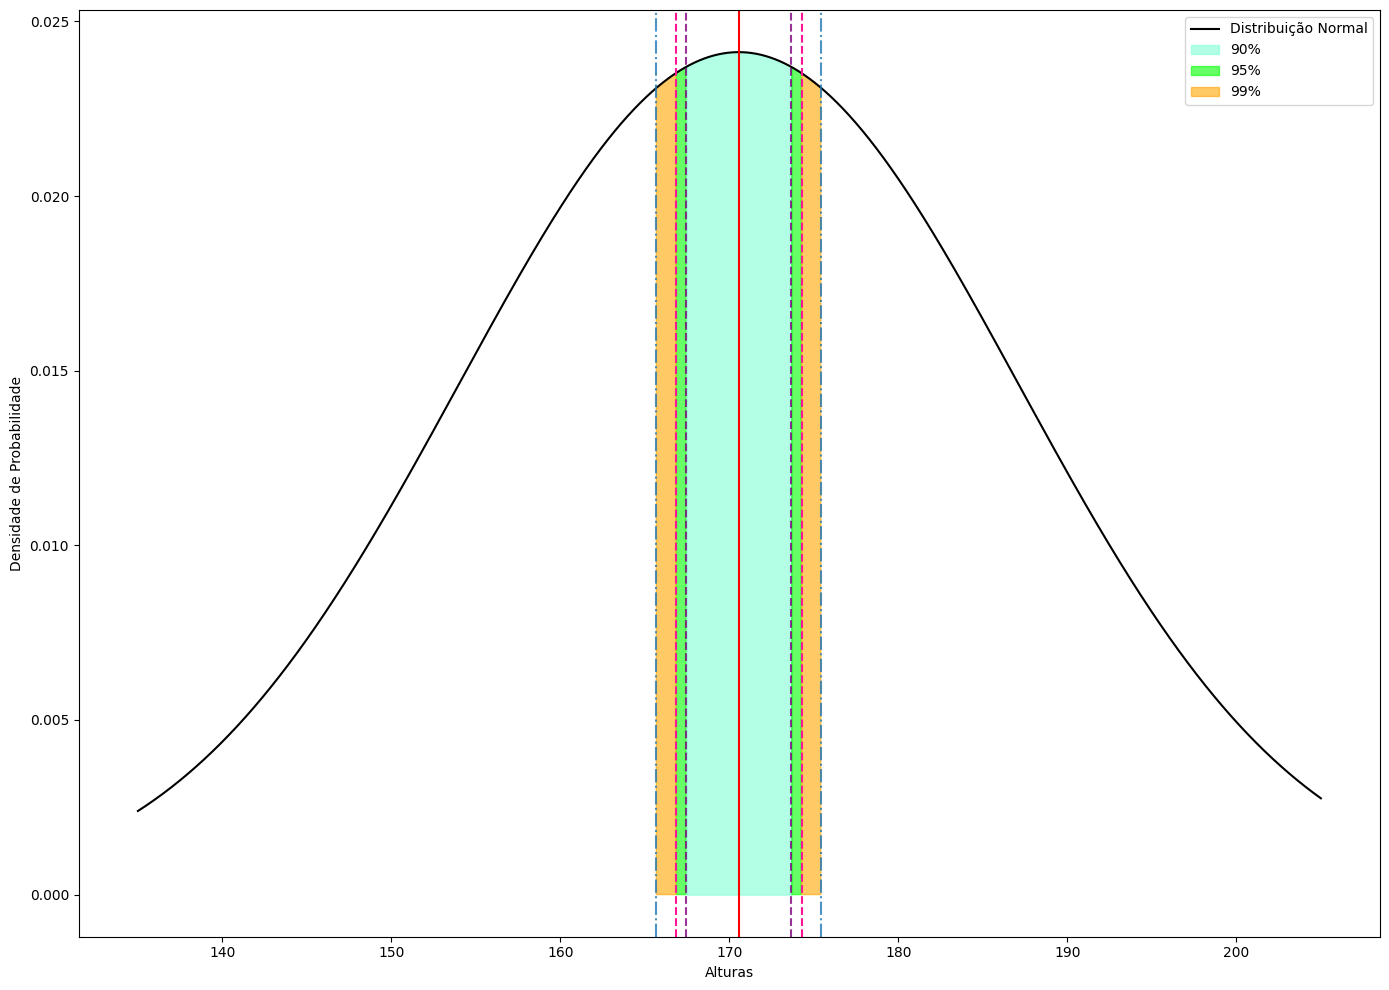

In [56]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm


intervalo_inferior1 = intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior1 = intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_inferior2 = intervalo_confianca_c1(1.960, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior2 = intervalo_confianca_c1(1.960, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_inferior3 = intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior3 = intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0)[2]


intervalo_x = np.linspace(135, 205, 2000)
p = norm.pdf(intervalo_x, loc=media_altura, scale=desvio_padrao)
plt.figure(figsize=(14, 10))

# Curva total
plt.plot(intervalo_x, p, color='black', label='Distribuição Normal')

# 90%
plt.fill_between( intervalo_x, p, where=(intervalo_x >= intervalo_inferior1) & (intervalo_x <= intervalo_superior1), alpha=0.6, label='90%', color='aquamarine' )

# 95%
plt.fill_between( intervalo_x, p, where=((intervalo_x >= intervalo_inferior2) & (intervalo_x <= intervalo_superior2)) & ~((intervalo_x >= intervalo_inferior1) & (intervalo_x <= intervalo_superior1)), alpha=0.6, label='95%', color='lime' )

# 99%
plt.fill_between( intervalo_x, p, where=((intervalo_x >= intervalo_inferior3) & (intervalo_x <= intervalo_superior3)) & ~((intervalo_x >= intervalo_inferior2) & (intervalo_x <= intervalo_superior2)), alpha=0.6, label='99%', color='orange' )

# Linhas verticais 
plt.axvline(media_altura, linestyle='-', alpha=1, color='red')

plt.axvline(intervalo_inferior1, linestyle='--', alpha=0.8, color='purple')
plt.axvline(intervalo_superior1, linestyle='--', alpha=0.8, color='purple')

plt.axvline(intervalo_inferior2, linestyle='--', alpha=1, color='deeppink')
plt.axvline(intervalo_superior2, linestyle='--', alpha=1, color='deeppink')

plt.axvline(intervalo_inferior3, linestyle='-.', alpha=0.8)
plt.axvline(intervalo_superior3, linestyle='-.', alpha=0.8)

plt.xlabel('Alturas')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.tight_layout()
plt.show()

## C $)$  P-value em um Teste de Hipótese

Utilizando a mesma base de dados da questão anterior, mas desta vez utilizando a distinção de gênero.  
O grupo de Controle será a amostra masculina, enquanto a amostra feminina será o grupo de teste.

In [57]:
masc = []                                                                  # Grupo de Controle: Alturas de Homens
fem = []                                                                   # Grupo de Teste: Alturas de Mulheres

with open('assets/atv_4/person_index.csv', encoding="utf-8") as arquivo2:  # Tratamento da base de dados para os testes de inferência
    leitor1 = csv.DictReader(arquivo2)
    for linha in leitor1:
        if linha["Gender"] == "Male":        
            masc.append(float(linha["Height"]) )
        if linha["Gender"] == "Female":
            fem.append(float(linha["Height"]))

print(f" Tamanho da Amostra de Controle(Altura de Homens): {len(masc)}\n Tamanho da Amostra de Teste(Altura de Mulheres): {len(fem)}")

 Tamanho da Amostra de Controle(Altura de Homens): 42
 Tamanho da Amostra de Teste(Altura de Mulheres): 34


Se nota que há uma diferença entre o tamanho das amostras **(Isso influênciará nos procedimentos posteriores)**.  
Será usado o T-teste de Welch, que tem a seguinte fórmula:  
$$t = \frac{x_1 + x_2}{\sqrt{ \frac{v_1}{n_1} + \frac{v_2}{n_2}}}$$

- $x_1$ e $x_2$ são as médias.
- $v_1$ e $v_2$ são as variâncias
- $n_1$ e $n_2$ são os tamanhos das amostras.  

Ele será usado justamente por causa dessa diferença nas amostras.

In [58]:
media_masculina = sum(masc) / len(masc)
media_feminina = sum(fem) / len(fem)

# alteração do csv(Linha 14, de 140 para 160)

df = pd.DataFrame({ "N° de Amostras": [len(masc), len(fem)], "Médias de cada grupo Amostral": [media_masculina, media_feminina]})
df.index = ["Masculino", "Feminino"]
df

,N° de Amostras,Médias de cada grupo Amostral
Masculino,42,174.809524
Feminino,34,165.294118


- Formulação da Hipótese Nula: $H_0 =$ *"A média de altura das mulheres é igual a dos homens"*  
Para toda Hipótese Nula tem de haver uma Hipótese Alternativa.
- Formulação da Hipótese Alternativa: $H_1 =$ *"A média de altura das mulheres é diferente da dos homens"*

Função: `stats.ttest_ind`
- Os seus dois primeiros parâmetros são as duas amostras.
- Diz respeito a dimensão dos dados (nesse caso não será usado).
- O quarto parâmetro fala sobre lidar com variâncias ou tamanhos de amostra desiguais entre as amostras.

In [60]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(masc, fem, axis=0, equal_var=False, alternative='two-sided')
print(t_stat, p_value)

nivel_significancia = 0.05

if(p_value < nivel_significancia):
    print(f"É correto afirmar, que há diferença entre a média de altura entre homens e mulheres, logo H0 é rejeitado.")

2.5879142139996025 0.011706280396804112
É correto afirmar, que há diferença entre a média de altura entre homens e mulheres, logo H0 é rejeitado.


Se pode perceber que o valor de probabilidade foi de $p_v = 0.01$,  
ao passo que o nível de significância é $ns=0.05$.

Dados estes valores, como o valor de probabilidade foi menor que o nível de significância, então a Hipótese Nula é rejeitada.

## D $)$ Nível de Significância

[Slide sobre Nível de Significância](assets/atv_4/Questao_D.pdf)

## E $)$ Reproduzindo slides em código


Dada uma amostra de dados sobre frequência de batimentos cardíacos, se tem o objetivo de descobrir o intervalo de confiança e o intervalo de proporção de população. 

Mas sabe-se que o número de amostras é $n=50$, além do mais a formula para o Intervalo de Confiança é:

$$ x ± t \cdot (\frac{s}{\sqrt n}) $$

E o intervalo de confiança da população é:
$$
\hat{p} \pm z \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

In [18]:
# Dados
bpm = [70.0, 81.8, 71.0, 80.8, 72.0, 79.8, 73.0, 78.8, 74.0, 77.8, 75.0, 76.8, 76.0, 75.8, 77.0, 74.8, 78.0, 73.8, 79.0, 72.8, 80.0, 71.8, 69.0, 82.8, 68.0, 83.8, 74.5, 77.3, 75.2, 76.6, 73.5, 78.3, 72.4, 79.4, 71.6, 80.2, 70.8, 81.0, 69.7, 82.1, 74.9, 76.9, 75.4, 76.4, 73.9, 77.9, 72.9, 78.9, 71.9, 79.9]

batimentos_categorico = [1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

def categorico(listaBinaria):
    contador = 0
    for i in range(len(listaBinaria)):
        if listaBinaria[i] == 1:
            contador += 1
    return contador

media_bpm = sum(bpm) / len(bpm)
proporcao_categorica = categorico(batimentos_categorico) / len(batimentos_categorico) # É a média d

variancia = (sum( ((bpm[i] - media_bpm)**2) for i in range(len(bpm)) )) / (len(bpm)-1)                             
desvio_padrao_bpm = math.sqrt(variancia)       


In [23]:
def intervalo_confianca(Zcritc, desvio, media, tamanho):                                                           # Função para calcula o Intervalo de Confiança: Intervalo de Confiaça Superior e Intervalo de Confiaça Inferior
    margem_erro = Zcritc * (desvio/ math.sqrt(tamanho - 1))
    intervalo_Superior = media + margem_erro
    intervalo_Inferior = media - margem_erro
    return media, intervalo_Inferior, intervalo_Superior, f'{(margem_erro):.3f}'

def intervalo_confianca_populacional(Zcrit, proporcao, tamanho):
    erro_padrao = math.sqrt((proporcao * (1-proporcao))/tamanho)
    intervalo_inferior = proporcao - Zcrit * erro_padrao
    intervalo_superior = proporcao + Zcrit * erro_padrao
    return intervalo_inferior, intervalo_superior, erro_padrao, proporcao

print(intervalo_confianca_populacional(1.96, proporcao_categorica, len(batimentos_categorico)))

print(intervalo_confianca(1.96, desvio_padrao_bpm, media_bpm, len(bpm)))


(0.0299252577022837, 0.21007474229771628, 0.04595650117230423, 0.12)
(75.9, 74.82284820011292, 76.9771517998871, '1.077')


## F $)$ 

In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# Dados dos Ratos

#x = [0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3] Dados usados em vídeo
#y = [1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3] Dados usados em vídeo

x = [0.9, 1.8, 2.4, 3.5, 4.6, 5.1, 5.3, 5.5, 6.3]
y = [1.5, 2.7, 1.1, 3.7, 3.4, 3.2, 5.4, 4.7, 6.3]

In [184]:
# Regressão Linear com o Scikit-Learn

# Conversão de listas para vetores np e resize no x
x = np.array(x)
y = np.array(y)
X = x.reshape(-1, 1)

# Regressão Linear propriamente
modelo_Regressao = LinearRegression()

modelo_Regressao.fit(X,y)

intercept = modelo_Regressao.intercept_     # Coeficiente Linear
slope = modelo_Regressao.coef_[0]           # Coeficiente Angular

reta_x = np.linspace(0, 7, 100)             # Para o gráfico
reta_y = intercept + slope * reta_x         # Reta Y após a Regressão

print(f"O coeficiente Angular(Slope): {slope:.4f}\nO coeficiente Linear(Intercept): {intercept:.4f}")

O coeficiente Angular(Slope): 0.7871
O coeficiente Linear(Intercept): 0.4598


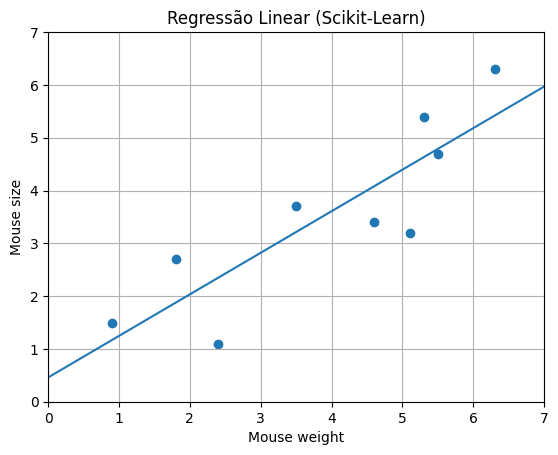

In [142]:
plt.scatter(x, y)
plt.plot(reta_x, reta_y)
plt.grid(True)
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.xlabel("Mouse weight")
plt.ylabel("Mouse size")
plt.title("Regressão Linear (Scikit-Learn)")
plt.show()

In [148]:
# Regressão Linear e Estatísticas com statsmodels

# Ajuste do X
X = sm.add_constant(x)
# Ajuste do modelo
modelo = sm.OLS(y, X).fit()
# Resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     20.10
Date:                Tue, 03 Feb 2026   Prob (F-statistic):            0.00286
Time:                        03:28:45   Log-Likelihood:                -10.979
No. Observations:                   9   AIC:                             25.96
Df Residuals:                       7   BIC:                             26.35
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4598      0.757      0.608      0.5

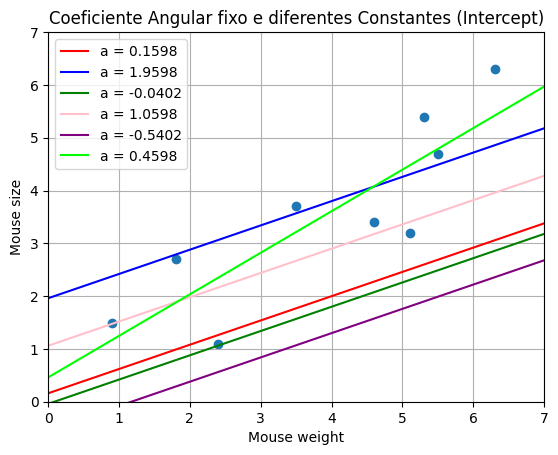

In [203]:
# Pegando valores do Coeficiente Angular e Coeficiente Linear
coeficientes = modelo.params
p_valor = modelo.pvalues
b_intercept = coeficientes[0] # Pegando o Coeficiente Linear(Intercept) que é o que vai mudar

a_slope = coeficientes[1]
intervalos_intercept = [b_intercept - 0.3, b_intercept + 1.5, b_intercept - 0.5, b_intercept + 0.6, b_intercept - 1]

# Gráfico

cores = ['red', 'blue', 'green', 'pink', 'purple', 'brown']

plt.scatter(x, y)

for a, cor in zip(intervalos_intercept, cores):
    y_linha = a + b_intercept * reta_x
    plt.plot(reta_x, y_linha, color=cor, label=f"a = {a:.4f}", alpha = 1)

plt.plot(reta_x, reta_y, color='lime', label=f'a = {b_intercept:.4f}')

plt.xlabel("Mouse weight")
plt.ylabel("Mouse size")
plt.title("Coeficiente Angular fixo e diferentes Constantes (Intercept)")
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.grid(True)
plt.legend()
plt.show()

R² (scikit-learn): 0.7416914176974259
[0.56267209 0.00285518]
R² para cada valor de a:

a = 0.460  →  R² = -0.0238
a = 0.160  →  R² = -0.3554
a = 1.960  →  R² = 0.5960
a = -0.040  →  R² = -0.6149
a = 1.060  →  R² = 0.4318
a = -0.540  →  R² = -1.3984


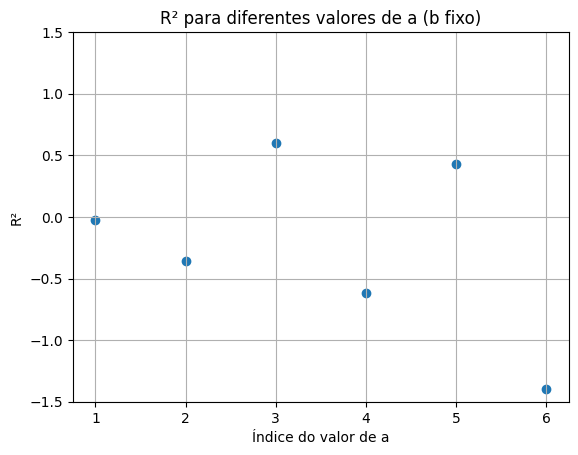

In [204]:
r2_sklearn = modelo_Regressao.score(X, y)
print("R² (scikit-learn):", r2_sklearn)

def R_SQUARED(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - ss_res / ss_tot

intervalos_intercept = [ b_intercept, b_intercept - 0.3, b_intercept + 1.5, b_intercept - 0.5, b_intercept + 0.6, b_intercept - 1]

print(p_valor)
print("R² para cada valor de a:\n")

rotacoes = []

for a in intervalos_intercept:
    y_pred = a + b_intercept * x
    r2 = R_SQUARED(y, y_pred)
    rotacoes.append(r2)
    print(f"a = {a:.3f}  →  R² = {r2:.4f}")



num = [1, 2, 3, 4, 5, 6]

plt.figure()
plt.scatter(range(1, 7), rotacoes)

plt.xlabel("Índice do valor de a")
plt.ylabel("R²")
plt.title("R² para diferentes valores de a (b fixo)")
plt.ylim(-1.5, 1.5)
plt.grid(True)

plt.show()

Análise: 
R² = 0,742 → o modelo explica 74,2% da variação dos dados (bom ajuste).

R² ajustado = 0,705 → ajuste continua bom mesmo penalizando o número de parâmetros.

F = 20,10 com p = 0,00286 → o modelo é estatisticamente significativo (p < 0,05), ou seja, a regressão linear é válida.

p-value do intercepto = 0,563
→ não significativo (p > 0,05).
O termo constante não é estatisticamente diferente de zero.

p-value do slope = 0,00286
→ significativo (p < 0,05).
Existe uma relação linear significativa entre x e y.

## G $)$

LU com Pivoteamento Parcial 

In [236]:
def LU_PP(matriz, dimensao):
    p = [i for i in range(dimensao)]

    for i  in range(dimensao):
        p[i] = i
    for k in range(dimensao - 1):
        pv = abs(matriz[k][k])
        r = k
        for i in range(k+1, dimensao):
            if abs(matriz[i][k]) > pv:
                pv = abs(matriz[i][k])
                r = i
        
        if pv == 0:
            print("A matriz é singular")
            break
        if r != k:
            aux = p[k]
            p[k] = p[r]
            p[r] = aux
            for j in range(dimensao):
                aux = matriz[k][j]
                matriz[k][j] = matriz[r][j]
                matriz[r][j] = aux
        for i in range (k+1, dimensao):
            m = matriz[i][k] / matriz[k][k]
            matriz[i][k] = m
            for j in range(k+1, dimensao):
                matriz[i][j] = matriz[i][j] - m * matriz[k][j]
    return matriz, p
    
def RSTriangular_C(b, p, tamanho):
    c = [0]*tamanho
    for i in range(tamanho):
        r = p[i]
        c[i] = b[r]
    return c

def RSTriangular_LY(matriz, c, tamanho):
    y = [0] * tamanho
    for i in range(tamanho):
        soma = 0
        for j in range(i):
            soma += matriz[i][j] * y[j]
        y[i] = c[i] - soma
    return y

def RSTriangular_UX(matriz, y, tamanho):
    x = [0] * tamanho

    for i in range(tamanho-1, -1, -1):
        soma = 0
        for j in range(i+1, tamanho):
            soma = soma + ( matriz[i][j] * x[j] )
        x[i] = (y[i] - soma) / matriz[i][i]
    return x



In [243]:
# Exemplo 7:
matriz_A = [[3, -4, 1],     # Linha 0 
            [1, 2, 2],      # Linha 1
            [4, 0, -3]]     # Linha 2
b = [9,3,-2]

LU, p = LU_PP(matriz_A, 3)
c = RSTriangular_C(b, p, 3)

print(f"Resultado da permutação das linhas,\nse obtém a LU : \n{LU[0]}\n{LU[1]}\n{LU[2]}\n")
print(f"O vetor p = {p}\n")
print("Resolução dos Sistemas Lineares Triangulares")
print(f"Dado o vetor b: {b}")
print(f"c = Pb: {c}\n")
y = RSTriangular_LY(LU, c, 3)
print(f"Ly = c: {y}\n")
x = RSTriangular_UX(LU, y, 3)


print("Solução x =", x)

Resultado da permutação das linhas,
se obtém a LU : 
[4, 0, -3]
[0.75, -4.0, 3.25]
[0.25, -0.5, 4.375]

O vetor p = [2, 0, 1]

Resolução dos Sistemas Lineares Triangulares
Dado o vetor b: [9, 3, -2]
c = Pb: [-2, 9, 3]

Ly = c: [-2, 10.5, 8.75]

Solução x = [1.0, -1.0, 2.0]
